In [15]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
# data path
forward_only_path = './Forward_only_entry_escape_cleaned_20241028.xlsx'
WT_path = './WT_entry_escape_cleaned_20241028.xlsx'

# read data
forward_only = pd.read_excel(forward_only_path)
WT = pd.read_excel(WT_path, skiprows=2) #skip 2 rows

In [17]:
# fill empty cells with previous non-empty value
# Field
forward_only['Field'] = forward_only['Field'].fillna(method='ffill')
WT['Field'] = WT['Field'].fillna(method='ffill')
# Well
forward_only['Well'] = forward_only['Well'].fillna(method='ffill')
WT['Well'] = WT['Well'].fillna(method='ffill')
# video_index
forward_only['video_index'] = forward_only['video_index'].fillna(method='ffill')
WT['video_index'] = WT['video_index'].fillna(method='ffill')
# time interval (ms)
forward_only['time interval (ms)'] = forward_only['time interval (ms)'].fillna(method='ffill')
WT['time interval (ms)'] = WT['time interval (ms)'].fillna(method='ffill')


In [18]:
# For 'forward_only', drop rows where 'notes' contains 'small' or 'medium' or 'abnormal'
forward_only = forward_only[~forward_only['notes'].astype(str).str.contains('small|medium|abnormal', na=False)]

# For 'WT', drop rows where 'notes' contains 'small' or 'medium' or 'abnormal'
WT = WT[~WT['notes'].astype(str).str.contains('small|medium|abnormal', na=False)]

# remove impeded backward motion modes
forward_only = forward_only[~forward_only['motion modes (not included multiple bugs) (c/s & s/c: between skating and circling) (bi: impeded backward; bi/b: impeded backward+backward)'].astype(str).str.contains('bi', na=False)]
WT = WT[~WT['motion modes (not included multiple bugs) (c/s & s/c: between skating and circling) (bi: impeded backward; bi/b: impeded backward+backward)'].astype(str).str.contains('bi', na=False)]


print(forward_only.shape)
# For 'forward_only', drop rows where the column after 'notes' (index 16) contains 'b'
forward_only = forward_only[~forward_only.iloc[:, 16].astype(str).str.contains('b', na=False)]
print(forward_only.shape)

(490, 19)
(483, 19)


In [19]:
# plot nonNan value in residence time(ms)
residence_time_forward_only = forward_only['residence time(ms)'].dropna()
residence_time_WT = WT['residence time(ms)'].dropna()
# keep only numeric value
residence_time_forward_only = pd.to_numeric(forward_only['residence time(ms)'], errors='coerce').dropna()
residence_time_WT = pd.to_numeric(WT['residence time(ms)'], errors='coerce').dropna()
# original unit is ms, convert to s
residence_time_forward_only = residence_time_forward_only / 1000
residence_time_WT = residence_time_WT / 1000

residence_time_forward_only_list = residence_time_forward_only.tolist()
residence_time_WT_list = residence_time_WT.tolist()
forward_only = np.array(residence_time_forward_only_list)
WT = np.array(residence_time_WT_list)

23.531428571428574
Forward Only - KS Statistic: 0.0686, p-value: 0.9040
Wild-Type - KS Statistic: 0.0799, p-value: 0.7477
R-squared (Forward Only): 0.9468337823874486
R-squared (WT): 0.994129354721144


Text(0, 0.5, 'Probability Density')

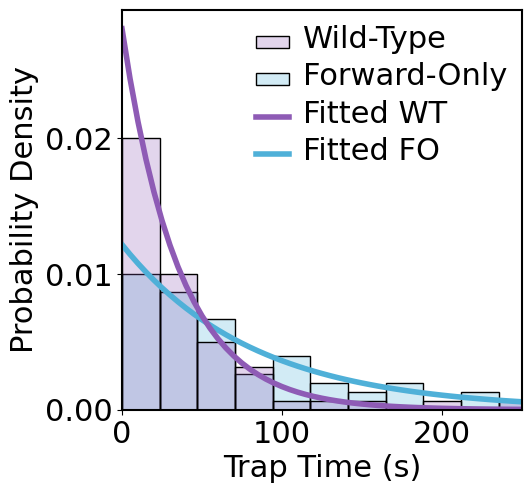

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

colors = ['#E89DA0', '#88CEE6', '#F6C8A8', '#B2D3A4', '#9FBA95', '#E6CECF', '#B696B6', '#80C1C4']
# purple: #A77BCA #8E5BB5
# blur: #4FB0D8 #56C1E1
# color_purple = '#A77BCA'
color_purple = '#8E5BB5'
color_blue = '#4FB0D8'
# color_blue = '#56C1E1'


# Define the common range for the histograms based on the min and max of both datasets
# min_value = min(np.min(forward_only), np.min(WT))
max_value = max(np.max(forward_only), np.max(WT))
min_value = 0
bins = np.linspace(min_value, max_value, 22)  # Define the number of bins as needed
# define bins_fit so that delta_t is 1
bins_fit = bins
# Calculate histograms
hist_forward, bin_edges_forward = np.histogram(forward_only, bins=bins_fit, density=True)
hist_WT, bin_edges_WT = np.histogram(WT, bins=bins_fit, density=True)

# Calculate midpoints of bins for fitting
x_forward = (bin_edges_forward[:-1] + bin_edges_forward[1:]) / 2
x_WT = (bin_edges_WT[:-1] + bin_edges_WT[1:]) / 2

# Calculate midpoints of bins for plotting
hist_forward_plot, bin_edges_forward_plot = np.histogram(forward_only, bins=bins, density=True)
hist_WT_plot, bin_edges_WT_plot = np.histogram(WT, bins=bins, density=True)
x_forward_plot = (bin_edges_forward_plot[:-1] + bin_edges_forward_plot[1:]) / 2
x_WT_plot = (bin_edges_WT_plot[:-1] + bin_edges_WT_plot[1:]) / 2

# Calculate bin width
delta_t = bins_fit[1] - bins_fit[0]
print(delta_t)

# Define the fitting function
def exponential(x, lambda_):
    return lambda_ * np.exp(-lambda_ * x)

# Initial guess for the parameter lambda
initial_guess_forward = 0.0120
initial_guess_WT = 0.0245

# Fit the function to the Forward Only data
params_forward, _ = curve_fit(exponential, x_forward, hist_forward, p0=initial_guess_forward)

# Fit the function to the WT data
params_WT, _ = curve_fit(exponential, x_WT, hist_WT, p0=initial_guess_WT)

# calculate r^2 from bins plot
residuals_forward = hist_forward_plot - exponential(x_forward_plot, params_forward[0])
ss_res_forward = np.sum(residuals_forward**2)
ss_tot_forward = np.sum((hist_forward_plot - np.mean(hist_forward_plot))**2)
r_squared_forward = 1 - (ss_res_forward / ss_tot_forward)

residuals_WT = hist_WT_plot - exponential(x_WT_plot, params_WT[0])
ss_res_WT = np.sum(residuals_WT**2)
ss_tot_WT = np.sum((hist_WT_plot - np.mean(hist_WT_plot))**2)
r_squared_WT = 1 - (ss_res_WT / ss_tot_WT)

# Generate data for plotting the fitted curves
x_fit_forward = np.linspace(min_value, max_value, 100)
y_fit_forward = exponential(x_fit_forward, params_forward[0])

x_fit_WT = np.linspace(min_value, max_value, 100)
y_fit_WT = exponential(x_fit_WT, params_WT[0])

# Plotting the histograms and fitted curves
# plt.figure(figsize=(6, 3.2))
plt.figure(figsize=(5, 5))
# sns.histplot(forward_only, bins=bins, stat='density', label='Forward-Only, N={}'.format(len(forward_only)), alpha=0.5, kde=False, zorder=1)
# sns.histplot(WT, bins=bins, stat='density', label='Wild-Type, N={}'.format(len(WT)), alpha=0.5, kde=False, zorder=2)
sns.histplot(forward_only, bins=bins, stat='density', label='Forward-Only, N={}'.format(len(forward_only)), alpha=0.25, kde=False, zorder=1, color=color_blue)
sns.histplot(WT, bins=bins, stat='density', label='Wild-Type, N={}'.format(len(WT)), alpha=0.25, kde=False, zorder=2, color=color_purple)

# plt.plot(x_fit_forward, y_fit_forward, linewidth=3, label='Fitted Forward-Only (R$^2$={:.3f})'.format(r_squared_forward))
# plt.plot(x_fit_WT, y_fit_WT, linewidth=3, label='Fitted Wild-Type (R$^2$={:.3f})'.format(r_squared_WT))

plt.plot(x_fit_forward, y_fit_forward, linewidth=4, label='Fitted Forward-Only (R$^2$={:.3f})'.format(r_squared_forward), color=color_blue)
plt.plot(x_fit_WT, y_fit_WT, linewidth=4, label='Fitted Wild-Type (R$^2$={:.3f})'.format(r_squared_WT), color=color_purple)

# plt.title('Distribution of Residence Times with Fitted Custom Exponential Distributions')
plt.xlabel('Trap Time (s)')
plt.ylabel('Probability Density')

# limits
plt.xlim(0, max_value)

# Get the current legend handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Reorder handles and labels so that histogram labels come first
order = [3, 2, 1, 0]  
plt.legend([handles[i] for i in order], [labels[i] for i in order], frameon=False, fontsize=12)

# edit label content
labels = [item.get_text() for item in ax.get_xticklabels()]
labels[0] = 'Wild-Type'
labels[1] = 'Forward-Only'
# labels[2] = 'Fitted Wild-Type'
# labels[3] = 'Fitted Forward-Only'
# --v4.7 font--
labels[2] = 'Fitted WT'
labels[3] = 'Fitted FO'
plt.legend([handles[i] for i in order], labels, frameon=False, fontsize=12)

# adjust x lim
plt.xlim(0, 250)

# # Print fitted parameters
# print("Fitted parameter (Forward Only p):", params_forward)
# print("Fitted parameter (WT p):", params_WT)
# print(params_WT/params_forward)
# print(params_WT/delta_t)
# print(params_forward/delta_t)
# print((3+2*3)/(3+2))

# Perform KS test
from scipy.stats import kstest
ks_stat_forward, p_value_forward = kstest(forward_only, 'expon', args=(0, 1/params_forward[0]))
ks_stat_WT, p_value_WT = kstest(WT, 'expon', args=(0, 1/params_WT[0]))

print(f"Forward Only - KS Statistic: {ks_stat_forward:.4f}, p-value: {p_value_forward:.4f}")
print(f"Wild-Type - KS Statistic: {ks_stat_WT:.4f}, p-value: {p_value_WT:.4f}")

# save lambda
lambda_forward = params_forward[0]
lambda_WT = params_WT[0]


# Print R-squared values
print("R-squared (Forward Only):", r_squared_forward)
print("R-squared (WT):", r_squared_WT)

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=18)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=18)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(18)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
ax.locator_params(axis='y', nbins=3)
ax.locator_params(axis='x', nbins=4)

# ---set box size---
def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

set_size(4, 4)

# --v4.7 font--
ax.tick_params(axis='both', which='major', labelsize=22)
if legend:
    for label in legend.get_texts():
        label.set_fontsize(22)
ax.set_xlabel(xlabel, fontsize=22)  
ax.set_ylabel(ylabel, fontsize=22)


# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('Trap Time PDF_narrow.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
# plt.savefig('Trap Time PDF_narrow_purple.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
